### More Pandas Tips and Tricks

In [5]:
# Import Libraries
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Data Import 
df = sns.load_dataset('titanic')

In [7]:
# Check the data
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Missing Values and imputing them 

In [8]:
# Find out the percentage of missing values
df.isnull().sum()/len(df)*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [9]:
# Drop the Column having more than 70 percent missing values from the dataset
df.drop('deck', axis=1, inplace=True)

In [10]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')

In [11]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
# flling missing values of age column by the mean of age
df['age'] = df['age'].fillna(df['age'].mean())

In [13]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [14]:
# Fill Embareked and Embarked Town with mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

In [17]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

<Axes: >

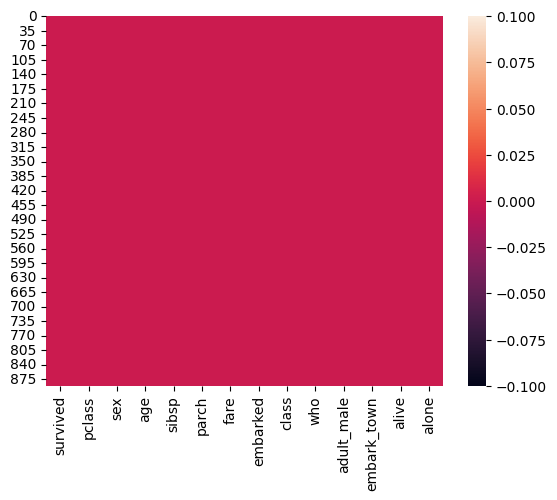

In [19]:
sns.heatmap(df.isnull())

### Assignment : If You do not impute missing values what will happen?

## Binning 

In [21]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [22]:
df.age.min()

np.float64(0.42)

In [23]:
df.age.max()

np.float64(80.0)

<Axes: xlabel='age', ylabel='Count'>

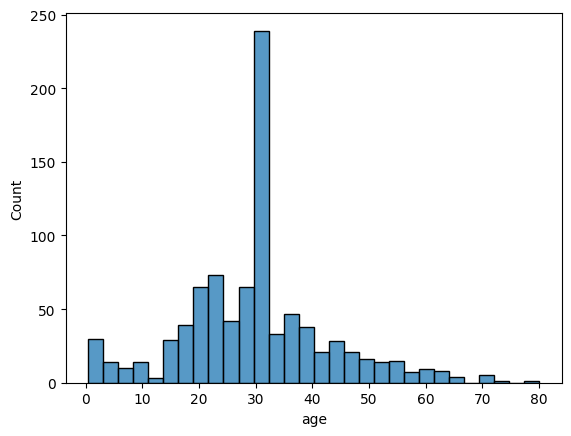

In [24]:
sns.histplot(df.age)

In [27]:
#  binning of age column into 7 categories
bins = [0, 1, 5, 12, 18, 30, 50, 80]
labels = ['Infant', 'Toddler', 'Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']

# Which column convert to bins
pd.cut(df['age'], bins=bins, labels=labels)

0      Young Adult
1            Adult
2      Young Adult
3            Adult
4            Adult
          ...     
886    Young Adult
887    Young Adult
888    Young Adult
889    Young Adult
890          Adult
Name: age, Length: 891, dtype: category
Categories (7, str): ['Infant' < 'Toddler' < 'Child' < 'Teenager' < 'Young Adult' < 'Adult' < 'Senior']

In [28]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Feature Engineering

In [29]:
#  binning of age column into 7 categories
bins = [0, 1, 5, 12, 18, 30, 50, 80]
labels = ['Infant', 'Toddler', 'Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']

# Which column convert to bins
df["Binned_Age"]=pd.cut(df['age'], bins=bins, labels=labels)

In [30]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,Binned_Age
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Adult


In [32]:
binned_age_counts = df['Binned_Age'].value_counts()
binned_age_counts

Binned_Age
Young Adult    447
Adult          241
Teenager        70
Senior          64
Toddler         30
Child           25
Infant          14
Name: count, dtype: int64

In [ ]:
# renaming a column name
df.rename(columns={'Binned_Age':'Age_Group'}, inplace=True)

In [34]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,Age_Group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Adult


## Data Filteration

In [35]:
# Filter Data Based on Columns
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'Age_Group'],
      dtype='str')

In [38]:
df_01 = df[["survived", "Age_Group", "fare", "class"]]

In [39]:
df_01

,survived,Age_Group,fare,class
0,0,Young Adult,7.2500,Third
1,1,Adult,71.2833,First
2,1,Young Adult,7.9250,Third
3,1,Adult,53.1000,First
4,0,Adult,8.0500,Third
...,...,...,...,...
886,0,Young Adult,13.0000,Second
887,1,Young Adult,30.0000,First
888,0,Young Adult,23.4500,Third
889,1,Young Adult,30.0000,First


In [40]:
df_01.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   survived   891 non-null    int64   
 1   Age_Group  891 non-null    category
 2   fare       891 non-null    float64 
 3   class      891 non-null    category
dtypes: category(2), float64(1), int64(1)
memory usage: 16.3 KB


In [41]:
df["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [45]:
# Filter the data based on the row columns
df_first_class = df[df["class"] == "First"]
df_first_class.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,Age_Group
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Adult
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,Senior
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,Southampton,yes,True,Senior
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,Southampton,yes,True,Young Adult


In [68]:
# lets select the passengers who paid more than 240 for the ticket
df_150 = df_01[df_01["fare"] > 150]
df_150.head()

,survived,Age_Group,fare,class
27,0,Young Adult,263.0000,First
88,1,Young Adult,263.0000,First
118,0,Young Adult,247.5208,First
258,1,Adult,512.3292,First
268,1,Senior,153.4625,First


In [69]:
df_150.info()

<class 'pandas.DataFrame'>
Index: 29 entries, 27 to 856
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   survived   29 non-null     int64   
 1   Age_Group  29 non-null     category
 2   fare       29 non-null     float64 
 3   class      29 non-null     category
dtypes: category(2), float64(1), int64(1)
memory usage: 1.2 KB


In [70]:
df_150["class"].value_counts()

class
First     29
Second     0
Third      0
Name: count, dtype: int64

In [74]:
# Add two filters based on class and fare
df_150_first_class = df_01[(df_01["fare"] > 150) & (df_01["class"] == "First")].sort_values(by="fare", ascending=False)
df_150_first_class.head()


,survived,Age_Group,fare,class
258,1,Adult,512.3292,First
737,1,Adult,512.3292,First
679,1,Adult,512.3292,First
27,0,Young Adult,263.0000,First
88,1,Young Adult,263.0000,First
